In [1]:
import itertools
import os, sys
import numpy as np
import pandas as pd
import cobra
from matplotlib import pyplot as plt
import requests
import projection_methods
import torch
import time
import seaborn as sns
from ge_processing import SampleNormalizationMethod, ArithmetizationMethod, process_full_ge, ge_to_reaction_activities
import swifter

In [2]:
# Set up gurobi or other optimizer license file if needed
# os.environ['GRB_LICENSE_FILE'] = "/path/to/your/gurobi.lic"
# os.environ['GRB_LICENSE_FILE'] = "../argo_comp1_grb_key/gurobi.lic"


In [3]:
%load_ext autoreload
%autoreload 2

# Load data

## Model

In [4]:
model = cobra.io.read_sbml_model("real_data_experiment_files/data/RECON1.xml") # a metabolic model in sbml format

Set parameter LicenseID to value 197246
Set parameter GURO_PAR_SPECIAL
Set parameter TokenServer to value "license.rc.princeton.edu"


In [5]:
len(model.metabolites), len(model.reactions), len(model.genes), len(model.compartments)

(2766, 3741, 1905, 8)

## Flux data (NCI60 exchanges and intracellular fluxes for A549, MCF7)

In [6]:
exchange_flux_data = pd.read_csv(("real_data_experiment_files/data/depmap_samples_nci60_exchange_data.csv")).set_index('Unnamed: 0')
# a csv with sample ids as index (agreeing with gene expression and intracellular data) and reaction ids as columns, plus one "sample_id" columns

In [7]:
intracellular_flux_data = pd.read_csv(("real_data_experiment_files/data/palsson_paper_intracellular_fractional_data.csv")).set_index('sample_id')
# a csv with sample ids as index (agreeing with gene expression and exchange data) and reaction ids as columns, plus one "sample_id" columns. 

# intracellular_flux_data = intracellular_flux_data.rename(columns={c: c.replace("_L(e)", "__L_e") for c in intracellular_flux_data.columns}) # conversions specific to name formats in data and Recon1 model.

print("intracellular #rxns: {}, #non-nan ACH-0000019: {}, # non-nan ACH-000682: {}, intersection: {}".format(
    len(intracellular_flux_data.columns), len(intracellular_flux_data.columns) - intracellular_flux_data.loc['ACH-000019'].isna().sum(),  len(intracellular_flux_data.columns) - intracellular_flux_data.loc['ACH-000681'].isna().sum(),
     len(intracellular_flux_data.columns) - (intracellular_flux_data.isna().sum() >= 1).sum()
))

intracellular #rxns: 41, #non-nan ACH-0000019: 27, # non-nan ACH-000682: 28, intersection: 14


In [8]:
joint_intracellular_and_exchanges = pd.merge(intracellular_flux_data, exchange_flux_data.loc[intracellular_flux_data.index], left_index=True, right_index=True)

In [9]:
# set model objective manually if desired (or if model has none)
model_objective = "S6T14g"
model.objective = model_objective
# maximize sense
model.objective.sense = 'max'

In [10]:
# for r in model.reactions:
#     r.bounds = (-1000, 1000)

bounds_epsilon = 1e-5

fva = cobra.flux_analysis.flux_variability_analysis(model,
                                                   fraction_of_optimum=0.9,
                                                   # pfba_factor=1.0,
                                                    loopless=False)

l_bounds_series = pd.Series(fva.minimum.to_numpy() - bounds_epsilon)
u_bounds_series = pd.Series(fva.maximum.to_numpy() + bounds_epsilon)

for r in model.reactions:
    r.bounds = (fva.loc[r.id]['minimum'] - bounds_epsilon, fva.loc[r.id]['maximum'] + bounds_epsilon)


NameError: name 'activities' is not defined

In [12]:
# m = model.copy()
x=0
for r in model.reactions:
    if r.bounds[0] == 0 and r.bounds[1] == 0:
        # print(r.id)
        pass
    if fva.loc[r.id]['minimum'] == 0 and fva.loc[r.id]['maximum'] == 0:
        x += 1
        # print(r.id)
print("Blocked: {}/{}".format(x, len(model.reactions)))
# x = cobra.flux_analysis.flux_variability_analysis(model, fraction_of_optimum=0.1, pfba_factor=1.0)
# x


Blocked: 1274/3741


## Prediction prep

In [15]:
S = cobra.util.array.create_stoichiometric_matrix(model).astype(float)
# projection = projection_methods.FbaProjectionLowMidConfidence(stoichiometric_matrix=S, unknown_indices=unknown_indices)

In [23]:
def full_apply(model, S, unknown_indices, known_indices, filtered_flux_df, l_bounds, u_bounds):
    if len(l_bounds.shape) == 1:
        # duplicate per sample
        l_bounds = np.tile(l_bounds.values, (len(filtered_flux_df), 1))
        u_bounds = np.tile(u_bounds.values, (len(filtered_flux_df), 1))

    filtered_flux_df = filtered_flux_df.copy()
    known_mat = np.zeros(shape=filtered_flux_df.shape, dtype=float)
    known_mat[:, known_indices] = 1
    mid_bounds = (l_bounds + u_bounds) / 2
    filtered_flux_df.loc[:, :] = np.where(known_mat, filtered_flux_df, mid_bounds)

    method_to_predictions = dict()
    # for known_indices, set l_bounds and u_bounds with a -+100% gap from measured value
    cur_l_bounds = l_bounds.copy()
    cur_u_bounds = u_bounds.copy()
    gap = abs(filtered_flux_df.iloc[:, known_indices]) * 1
    cur_l_bounds[:, known_indices] = filtered_flux_df.iloc[:, known_indices] - gap
    cur_u_bounds[:, known_indices] = filtered_flux_df.iloc[:, known_indices] + gap
    for method in methods:
        orig_method = method
        partial_fixed_iterators = itertools.product([False, True], [False, True])
        bound_fixing_kind_iterators = ["raw", "scale", "clip"]
        for (is_partial, is_fixed) in partial_fixed_iterators:
            # try:
            name = str(method)
            print("pre qualified name:", name)
            # gc.collect()
            # torch.cuda.empty_cache()
            considered_unknown_indices = unknown_indices if is_partial else []
            considered_known_indices = known_indices if is_fixed else []
            method = orig_method
            start_time = time.time()
            projection = method(stoichiometric_matrix=S, 
                          projection_class=orig_method, n_iters=40, slope=0.01, input_mix_fraction=0.95,
                          model=model, unknown_indices=considered_unknown_indices, measured_indices=considered_known_indices, 
                          # steady_state_basis_matrix=basis, 
                          objective_id=model_objective,
                          l_bounds=cur_l_bounds, u_bounds=cur_u_bounds, 
                          acond=1e-3, rconed=1e-3,
                          dtype=torch.float, device=torch.device('cpu'))                    
            try:
                projection = projection.to(dtype=float)
            except Exception:
                pass
            name = str(projection)    
            predictions = projection.forward(torch.tensor(filtered_flux_df.values, dtype=float, device=torch.device('cpu')), l_bounds=cur_l_bounds, u_bounds=cur_u_bounds)
            predictions = pd.DataFrame(index=filtered_flux_df.index, columns=[r.id for r in model.reactions], data=predictions.cpu().numpy())
        
            end_time = time.time()
    
            print(f"Time taken for {name}: {end_time - start_time:.2f} seconds")
            method_to_predictions[name] = predictions
            # except Exception:
            #     pass
            if orig_method != projection_methods.FBApro:
                break
    return method_to_predictions

In [24]:
def leave_one_out_apply(model, S, unknown_indices, known_indices, filtered_flux_df, l_bounds, u_bounds):
    
    if len(l_bounds.shape) == 1:
        # duplicate per sample
        l_bounds = np.tile(l_bounds.values, (len(filtered_flux_df), 1))
        u_bounds = np.tile(u_bounds.values, (len(filtered_flux_df), 1))
    
    # filtered_flux_df = filtered_flux_df.iloc[:4, :]
    # l_bounds = l_bounds[:4]
    # u_bounds = u_bounds[:4]

    filtered_flux_df = filtered_flux_df.copy()
    known_mat = np.zeros(shape=filtered_flux_df.shape, dtype=float)
    known_mat[:, known_indices] = 1
    mid_bounds = (l_bounds + u_bounds) / 2
    filtered_flux_df.loc[:, :] = np.where(known_mat, filtered_flux_df, mid_bounds)

    
    method_to_predictions = dict()
    for method in methods:
        orig_method = method
        partial_fixed_iterators = itertools.product([False, True], [False, True])
        bound_fixing_kind_iterators = ["raw", "scale", "clip"]
        for bound_fixing_kind in partial_fixed_iterators:
            # try:
            name = str(method)
            print("pre qualified name:", name)
            # gc.collect()
            # torch.cuda.empty_cache()
            start_time = time.time()
            predictions = pd.DataFrame(index=filtered_flux_df.index, columns=[col for i, col in enumerate(model.reactions.list_attr('id')) if i in known_indices])    
                
            for i, cur in enumerate(known_indices):
                # if i >= 3:
                #     continue
                col = model.reactions[cur].id
                held_out_reference_fluxes = filtered_flux_df.copy()
                shape = held_out_reference_fluxes.shape
                held_out_reference_fluxes.loc[:, col] = mid_bounds[:, cur] # 0
                assert held_out_reference_fluxes.shape == shape
                held_out_unknown_indices = unknown_indices.copy()
                held_out_unknown_indices.append(cur)
                held_out_known_indices = known_indices.copy()
                held_out_known_indices.remove(cur)
                # create context-specific l_bounds and u_bounds with -+100% gap on the measured value for each index in held_out_known_indices
                cur_l_bounds = l_bounds.copy()
                cur_u_bounds = u_bounds.copy()
                for idx in held_out_known_indices:
                    gap = abs(held_out_reference_fluxes.iloc[:, idx]) * 1
                    cur_l_bounds[:, idx] = held_out_reference_fluxes.iloc[:, idx].values - gap
                    cur_u_bounds[:, idx] = held_out_reference_fluxes.iloc[:, idx].values + gap
                                    
                considered_unknown_indices = held_out_unknown_indices if is_partial else []
                considered_known_indices = held_out_known_indices if is_fixed else []
                method = orig_method
                projection = method(stoichiometric_matrix=S, 
                              projection_class=orig_method, n_iters=40, slope=0.01, input_mix_fraction=0.95,
                              model=model, unknown_indices=considered_unknown_indices, measured_indices=considered_known_indices, 
                              # steady_state_basis_matrix=basis, 
                              objective_id=model_objective,
                              l_bounds=cur_l_bounds, u_bounds=cur_u_bounds, 
                              acond=1e-3, rconed=1e-3,
                              dtype=torch.float, device=torch.device('cpu'))                    
                try:
                    projection = projection.to(dtype=float)
                except Exception:
                    pass
                name = str(projection)
                res = projection.forward(torch.tensor(held_out_reference_fluxes.values, device=torch.device('cpu'), dtype=float), l_bounds=cur_l_bounds, u_bounds=cur_u_bounds)
                predictions[col] = res.cpu().numpy()[:, cur]    
            end_time = time.time()
            print(f"Time taken for {name}: {end_time - start_time:.2f} seconds")
            method_to_predictions[name] = predictions
            if orig_method != projection_methods.FBApro:
                break
            # except Exception as e:
            #     print("Error running method {}".format(method))
            #     print(e)
            #     pass
    return method_to_predictions

# Exchange fluxes

### Compute predictions

In [27]:
methods = [
    projection_methods.FBAWrapper,
    projection_methods.FBApro, 
    # projection_methods.IMATWrapper,
    # projection_methods.MoMAWrapper
]

In [28]:
filtered_flux_df = exchange_flux_data
reference_fluxes = torch.zeros((len(filtered_flux_df.index), len(model.reactions)), dtype=torch.float32, device='cpu')
known_indices = []
unknown_indices = list(range(len(model.reactions)))
for i, r in enumerate(model.reactions.list_attr('id')):
    if "EX_" in r:
        reaction = model.reactions.get_by_id(r)
        # print(r, len(reaction.reactants), len(reaction.products))
        # for m in reaction.metabolites:
        #     if reaction.get_coefficient(m) != -1:
        #         print(reaction.get_coefficient(m))
        # try to find the "_c" version of r in the intracellular rates
        if r in filtered_flux_df.columns:
            # take the mean of the fluxes across all time points
            reference_fluxes[:, i] = torch.tensor(filtered_flux_df[r].values)
            known_indices.append(i)
            unknown_indices.remove(i)
        else:
            reference_fluxes[:, i] = 0
    else:
        reference_fluxes[:, i] = 0
# make reference_fluxes into a df
reference_fluxes = pd.DataFrame(index=filtered_flux_df.index, columns=[r.id for r in model.reactions], data=reference_fluxes.cpu().numpy())
all_reference_fluxes = reference_fluxes

In [30]:
wildtype_method_to_predictions = full_apply(model, S, unknown_indices, known_indices, reference_fluxes, l_bounds_series, u_bounds_series)

pre qualified name: <class 'projection_methods.FBAWrapper'>
Time taken for FBA: 3.50 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 7.23e-13, abs max: 1.30e+06, abs mean: 1.22e+05
S * output - abs min: 0.00e+00, abs max: 7.76e+00, abs mean: 8.94e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.05 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 0.00e+00, abs max: 1.34e+03, abs mean: 1.67e-01
S * output - abs min: 0.00e+00, abs max: 1.34e+03, abs mean: 2.26e-01
Suppressing further warnings.
Time taken for FBAproFixed: 20.79 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 2.32e-18, abs max: 5.07e+02, abs mean: 8.01e-01
S * output - abs min: 0.00e+00, abs max: 1.91e-04, abs mean: 1.22e-06
Suppressing further warnings.
Time taken for FBAproPartial: 18.93 seconds
pre qualified name: <class 'projection_methods.FBApro'>
input x - abs min: 0.00e+00, abs max: 5.00e+05, abs mean:

TypeError: rand_like(): argument 'input' (position 1) must be Tensor, not DataFrame

In [61]:
noise_power = 5e-1

method_to_abs_differences = {method: [] for method in wildtype_method_to_predictions.keys()}

for i in range(1):
    print("iteration", i)
    temp_reference_fluxes = reference_fluxes.copy()
    rand = pd.DataFrame(np.random.rand(*temp_reference_fluxes.shape), columns=temp_reference_fluxes.columns)

    temp_reference_fluxes *= (1 + 2 * (rand - 0.5) * noise_power)

    temp_l = l_bounds_series.copy()
    temp_u = u_bounds_series.copy()

    rand = pd.Series(np.random.rand(len(temp_l)), index=temp_l.index)
                        
    temp_l -= abs(rand)
    temp_u += abs(rand)
    
    perturbed_method_to_predictions = full_apply(model, S, unknown_indices, known_indices, reference_fluxes, temp_l, temp_u)
    for method, vals in perturbed_method_to_predictions.items():
        method_to_abs_differences[method].extend(list(
            np.abs((vals - wildtype_method_to_predictions[method])/wildtype_method_to_predictions[method]).values.flatten()))

iteration 0
pre qualified name: <class 'projection_methods.FBAWrapper'>
Time taken for FBA: 15.31 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 7.23e-13, abs max: 1.30e+06, abs mean: 1.22e+05
S * output - abs min: 0.00e+00, abs max: 7.76e+00, abs mean: 8.94e-02
Suppressing further warnings.
Time taken for FBAproBasic: 18.65 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 0.00e+00, abs max: 1.34e+03, abs mean: 1.67e-01
S * output - abs min: 0.00e+00, abs max: 1.34e+03, abs mean: 2.26e-01
Suppressing further warnings.
Time taken for FBAproFixed: 20.36 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 2.32e-18, abs max: 5.07e+02, abs mean: 8.01e-01
S * output - abs min: 0.00e+00, abs max: 1.91e-04, abs mean: 1.22e-06
Suppressing further warnings.
Time taken for FBAproPartial: 18.30 seconds
pre qualified name: <class 'projection_methods.FBApro'>
input x - abs min: 0.00e+00, abs max: 5.00e+

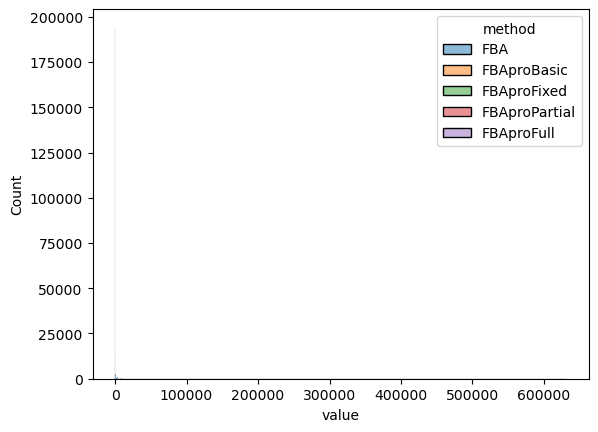

In [62]:
entries = []
for key, values in method_to_abs_differences.items():
    for value in values:
        entries.append({'method': key, 'value': value})
df = pd.DataFrame(entries)

sns.histplot(data=df, x='value', hue='method')
plt.show()

In [63]:
df.groupby('method').std()

,value
method,
FBA,NaN
FBAproBasic,2.412253e-11
FBAproFixed,0.000000e+00
FBAproFull,9.163458e-13
FBAproPartial,0.000000e+00


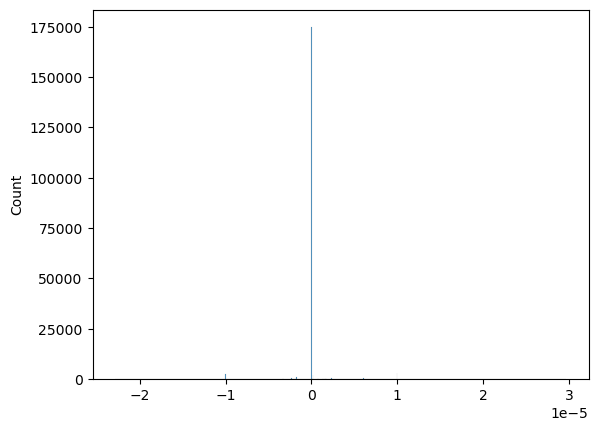

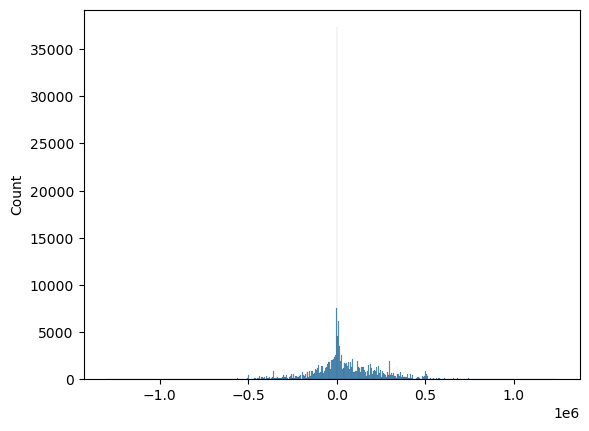

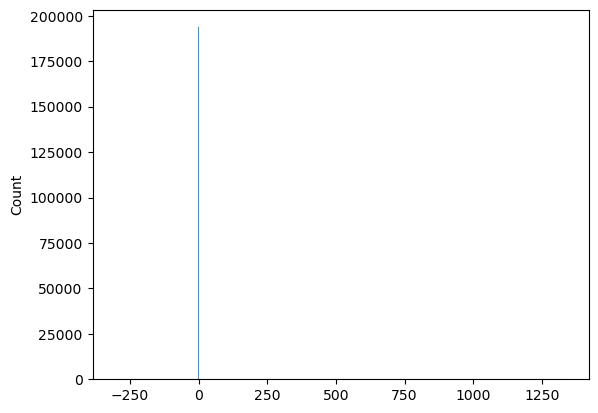

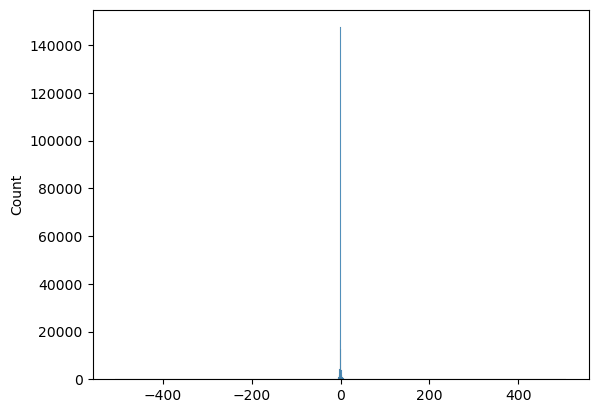

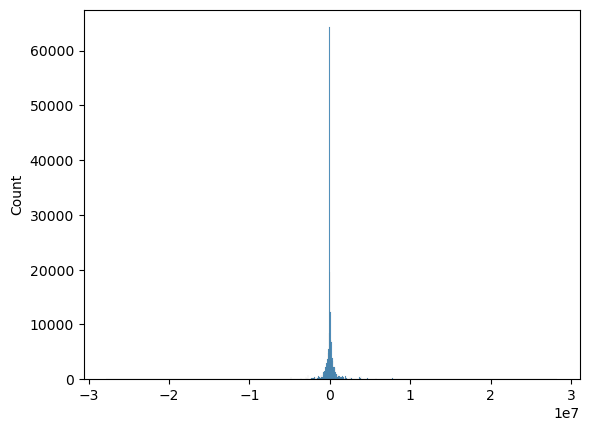

In [40]:
for m, vals in wildtype_method_to_predictions.items():
    sns.histplot(vals.values.flatten())
    plt.show()

# Randomly sampled data

### Compute predictions

In [105]:
methods = [
    projection_methods.FBAWrapper,
    projection_methods.FBApro, 
    # projection_methods.IMATWrapper,
    # projection_methods.MoMAWrapper
]

In [106]:
steady_states = cobra.sampling.sample(model, n=10, method='achr')
steady_states = steady_states.values

Read LP format model from file /tmp/tmpttppwbd6.lp
Reading time = 0.02 seconds
: 2766 rows, 7482 columns, 28598 nonzeros


In [110]:
steady_states.shape

(10, 3741)

In [108]:
reference_fluxes = pd.DataFrame(steady_states, columns=[r.id for r in model.reactions])
known_indices = []
unknown_indices = []

In [ ]:
wildtype_method_to_predictions = full_apply(model, S, unknown_indices, known_indices, reference_fluxes, l_bounds_series, u_bounds_series)

pre qualified name: <class 'projection_methods.FBAWrapper'>
Time taken for FBA: 0.73 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.30 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.26 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.28 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.

In [ ]:
noise_power = 1e-2

method_to_abs_differences = {method: [] for method in wildtype_method_to_predictions.keys()}

for i in range(5):
    print("iteration", i)
    temp_reference_fluxes = reference_fluxes.copy()
    rand = pd.DataFrame(np.random.rand(*temp_reference_fluxes.shape), columns=temp_reference_fluxes.columns)

    temp_reference_fluxes *= (1 + 2 * (rand - 0.5) * noise_power)

    temp_l = l_bounds_series.copy()
    temp_u = u_bounds_series.copy()

    rand = pd.Series(np.random.rand(len(temp_l)), index=temp_l.index)
                        
    temp_l -= abs(rand)
    temp_u += abs(rand)
    
    perturbed_method_to_predictions = full_apply(model, S, unknown_indices, known_indices, reference_fluxes, temp_l, temp_u)
    for method, vals in perturbed_method_to_predictions.items():
        method_to_abs_differences[method].extend(list(
            np.abs((vals - wildtype_method_to_predictions[method])/wildtype_method_to_predictions[method]).values.flatten()))

iteration 0
pre qualified name: <class 'projection_methods.FBAWrapper'>
Time taken for FBA: 4.10 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.23 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.25 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.30 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, 

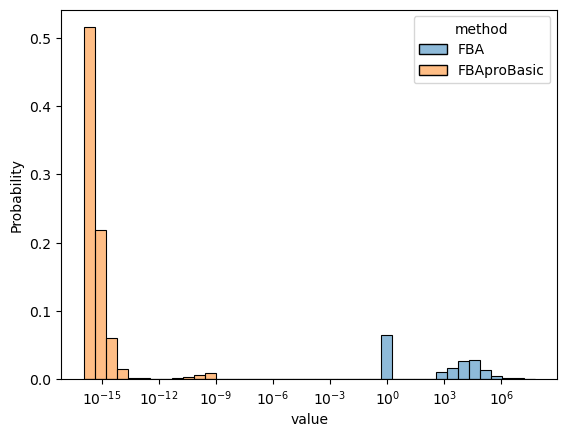

In [ ]:
entries = []
for key, values in method_to_abs_differences.items():
    for value in values:
        entries.append({'method': key, 'value': value})
df = pd.DataFrame(entries)

sns.histplot(data=df, x='value', hue='method', stat='probability', log_scale=True)
plt.show()

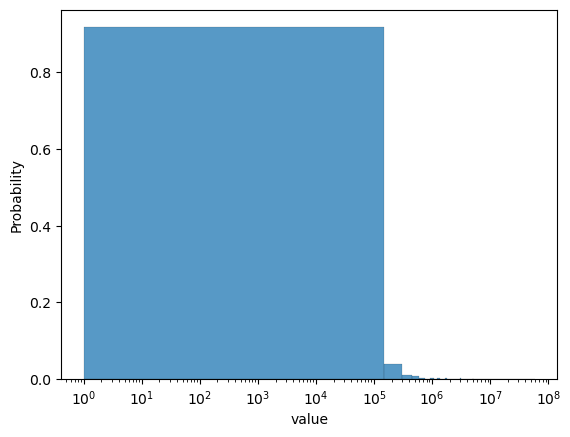

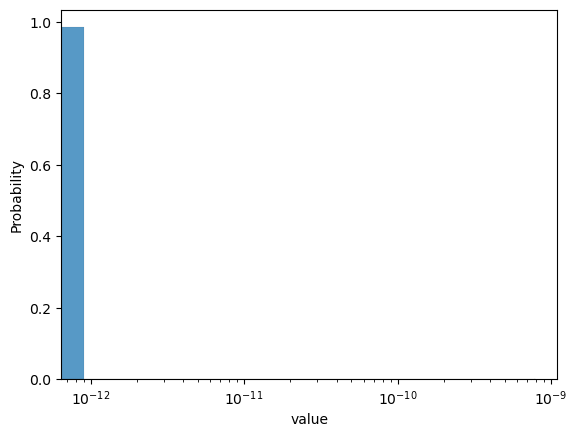

In [ ]:
for group, vals in df.groupby('method'):
    sns.histplot(data=vals, x='value', stat='probability')
    plt.xscale('log')
    plt.show()

In [ ]:
df.groupby('method').agg(lambda s: s.isnull().sum() / s.size)

,value
method,
FBA,0.604972
FBAproBasic,0.000000


In [ ]:
df.groupby('method').std()

,value
method,
FBA,NaN
FBAproBasic,5.834559e-11


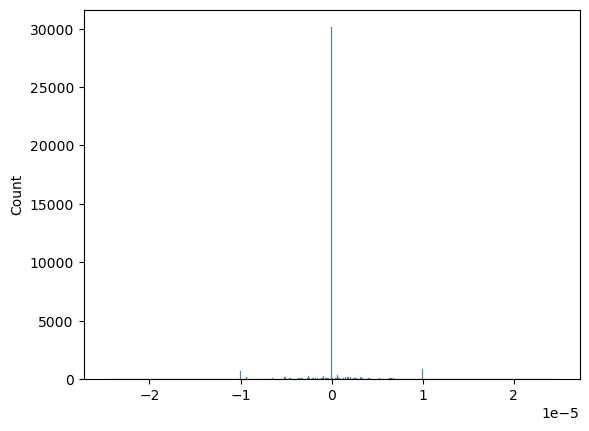

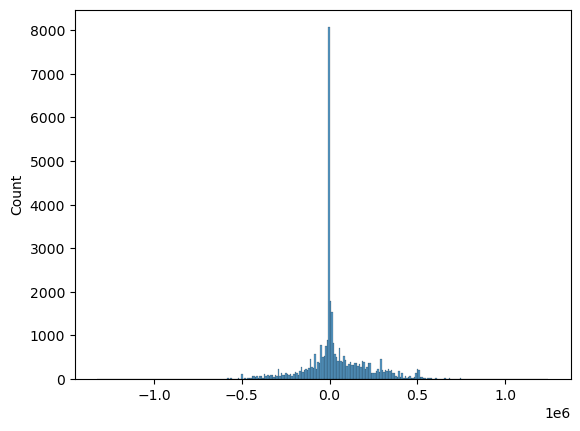

In [ ]:
for m, vals in wildtype_method_to_predictions.items():
    sns.histplot(vals.values.flatten())
    plt.show()

# Randomly sampled data again, but difference not normalized by value

### Compute predictions

In [ ]:
methods = [
    projection_methods.FBAWrapper,
    projection_methods.FBApro, 
    # projection_methods.IMATWrapper,
    # projection_methods.MoMAWrapper
]

In [ ]:
steady_states = cobra.sampling.sample(model, n=10, method='achr')
steady_states = steady_states.values

Read LP format model from file /tmp/tmpeagla248.lp
Reading time = 0.02 seconds
: 2766 rows, 7482 columns, 28598 nonzeros


In [ ]:
steady_states.shape

(10, 3741)

In [ ]:
reference_fluxes = pd.DataFrame(steady_states, columns=[r.id for r in model.reactions])
known_indices = []
unknown_indices = []

In [ ]:
wildtype_method_to_predictions = full_apply(model, S, unknown_indices, known_indices, reference_fluxes, l_bounds_series, u_bounds_series)

pre qualified name: <class 'projection_methods.FBAWrapper'>
Time taken for FBA: 0.80 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.34 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.25 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.20 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.

In [ ]:
noise_power = 1e-2

method_to_abs_differences = {method: [] for method in wildtype_method_to_predictions.keys()}

for i in range(5):
    print("iteration", i)
    temp_reference_fluxes = reference_fluxes.copy()
    rand = pd.DataFrame(np.random.rand(*temp_reference_fluxes.shape), columns=temp_reference_fluxes.columns)

    temp_reference_fluxes *= (1 + 2 * (rand - 0.5) * noise_power)

    temp_l = l_bounds_series.copy()
    temp_u = u_bounds_series.copy()

    rand = pd.Series(np.random.rand(len(temp_l)), index=temp_l.index)
                        
    temp_l -= abs(rand)
    temp_u += abs(rand)
    
    perturbed_method_to_predictions = full_apply(model, S, unknown_indices, known_indices, reference_fluxes, temp_l, temp_u)
    for method, vals in perturbed_method_to_predictions.items():
        method_to_abs_differences[method].extend(list(
            np.abs((vals - wildtype_method_to_predictions[method])).values.flatten()))

iteration 0
pre qualified name: <class 'projection_methods.FBAWrapper'>
Time taken for FBA: 2.89 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.14 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.15 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, abs mean: 1.23e+05
S * output - abs min: 0.00e+00, abs max: 7.79e+00, abs mean: 9.01e-02
Suppressing further warnings.
Time taken for FBAproBasic: 19.29 seconds
pre qualified name: <class 'projection_methods.FBApro'>
output - abs min: 3.62e-12, abs max: 1.32e+06, 

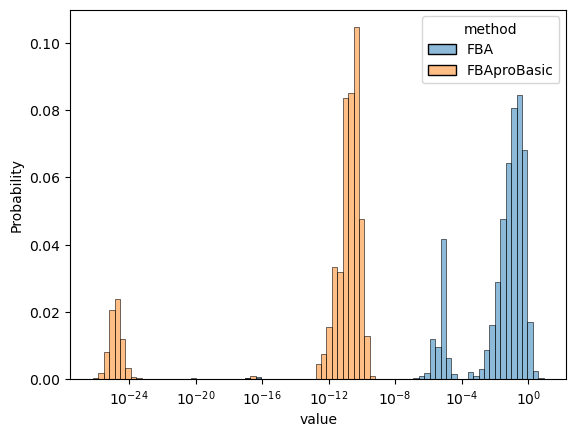

In [ ]:
entries = []
for key, values in method_to_abs_differences.items():
    for value in values:
        entries.append({'method': key, 'value': value})
df = pd.DataFrame(entries)

sns.histplot(data=df, x='value', hue='method', stat='probability', log_scale=True)
plt.show()

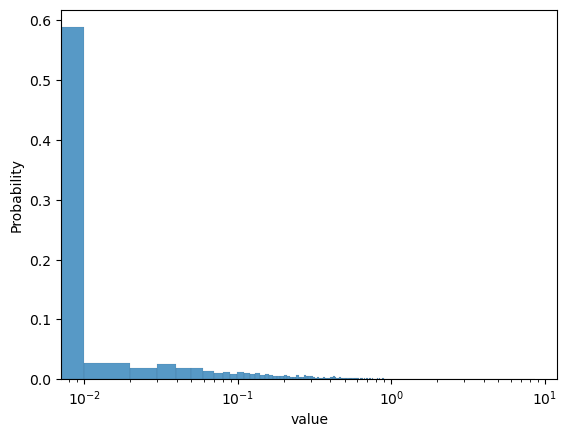

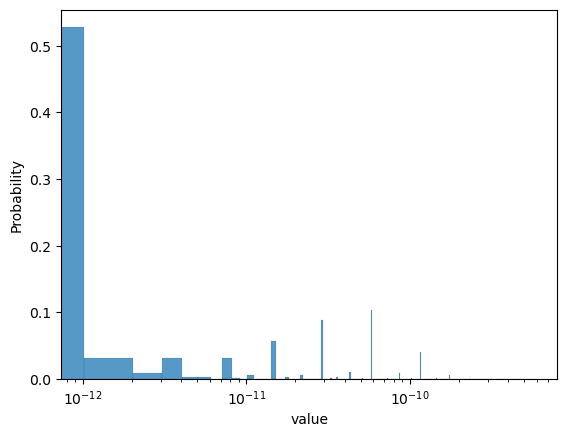

In [ ]:
for group, vals in df.groupby('method'):
    sns.histplot(data=vals, x='value', stat='probability')
    plt.xscale('log')
    plt.show()

In [ ]:
df.groupby('method').agg(lambda s: s.isnull().sum() / s.size)

,value
method,
FBA,0.0
FBAproBasic,0.0


In [ ]:
df.groupby('method').std()

,value
method,
FBA,2.802453e-01
FBAproBasic,3.880774e-11


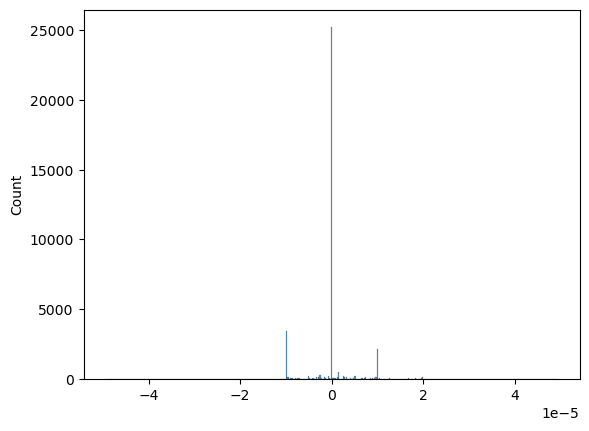

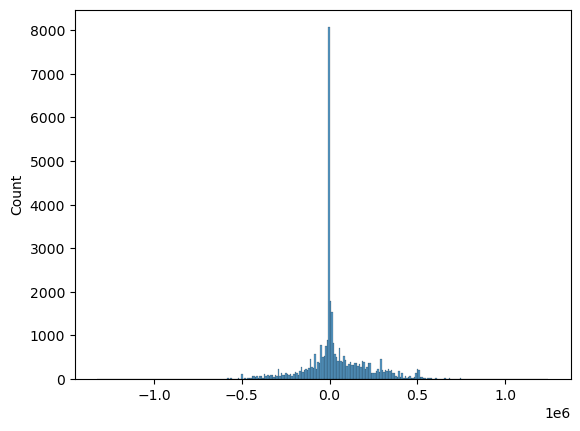

In [ ]:
for m, vals in wildtype_method_to_predictions.items():
    sns.histplot(vals.values.flatten())
    plt.show()